# Taylor / Maclaurin series

**Maths AA HL - AHL 5.19**

A Taylor polynomial is the best polynomial copy of a function near one point.
Adding terms widens the region where the copy is good.

Run the cells in order (Shift+Enter).

In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## The polynomial

$\sin(x) = x - \dfrac{x^3}{3!} + \dfrac{x^5}{5!} - \dots$

Only odd powers appear, so `n_terms` counts the **non-zero** terms.

In [2]:
def taylor_sin(x, n_terms):
    """Maclaurin polynomial of sin(x) using n_terms non-zero terms."""
    total = np.zeros_like(x)
    for k in range(n_terms):
        power = 2 * k + 1
        total = total + ((-1) ** k) * x**power / math.factorial(power)
    return total

## One snapshot first

Change `n` and re-run this cell to see a single polynomial.

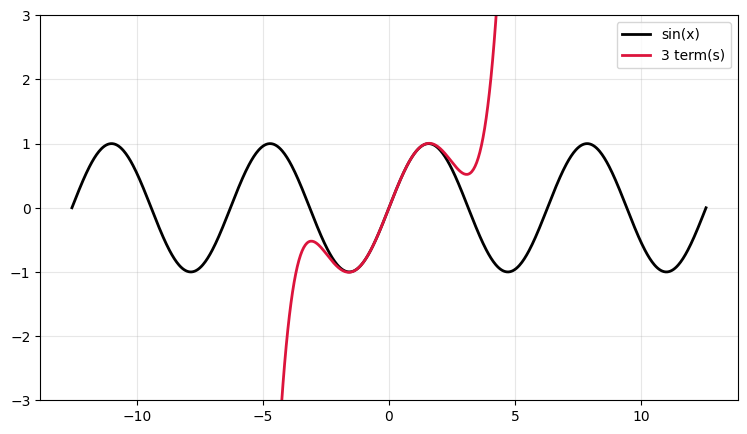

In [3]:
n = 3

x = np.linspace(-4 * np.pi, 4 * np.pi, 800)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, np.sin(x), color="black", lw=2, label="sin(x)")
ax.plot(x, taylor_sin(x, n), color="crimson", lw=2, label=f"{n} term(s)")
ax.set_ylim(-3, 3)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Now animate it

`to_jshtml()` renders the animation as a player inside the notebook, so this
works in plain Jupyter, VS Code and Colab without any extra packages.

In [4]:
MAX_TERMS = 10

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, np.sin(x), color="black", lw=2, label="sin(x)")
approx_line, = ax.plot([], [], color="crimson", lw=2, label="Taylor polynomial")
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_ylim(-3, 3)
ax.set_xlim(x[0], x[-1])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
title = ax.set_title("")


def frame(i):
    n = i + 1
    approx_line.set_data(x, taylor_sin(x, n))
    title.set_text(f"{n} term(s) - polynomial up to x^{2 * n - 1}")
    return approx_line, title


anim = FuncAnimation(fig, frame, frames=MAX_TERMS, interval=900, blit=False)
plt.close(fig)          # stop the static duplicate figure appearing
HTML(anim.to_jshtml())

## Try changing

- `MAX_TERMS` - how many terms to build up to.
- Swap in $\ln(1+x)$, whose series only converges for $|x| < 1$. The animation
  makes that boundary obvious: outside it, more terms make things **worse**.